In [ ]:
import numpy as np
import pandas as pd
import os
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pickle

: 

In [ ]:
import tessutils as tu
TIC = 375038081 #177162802

In [ ]:
from pathlib import Path

BASE = Path("C:/Users/michi/Documents/Git/data")  # gebruik / hier
BASE.mkdir(parents=True, exist_ok=True)
print(BASE)

C:\Users\michi\Documents\Git\data


In [ ]:
tu.reduction.download_tpf(TIC, outputdir='./spbstars/spb2')

Skipped: Already downloaded sectors for TIC=375038081: 6,5,4,3,1,2,10,13,11,12,8,7,9,27,33,30,32,31,28,29,39,36,37,38,34,35,68,61,67,66,69,65,64,63,62,87,96,93,94,95,88,89,90,97.
Skipped: No new images to download for TIC=375038081.


In [ ]:
from pathlib import Path
TPF_files = [str(file) for file in Path('./spbstars/spb2').glob(f'tic{TIC}_sec*.fits')]
tu.reduction.extract_light_curve(TPF_files, outputdir="./spbstars/cleaned/processed_spb2", progressbar=True, ncores=None, max_num_of_pc=20, return_msg=True, verbose=True, overwrite=False)

100%|██████████| 44/44 [00:20<00:00,  2.18it/s]


In [ ]:
tu.reduction.group_lcs(inputdir='./spbstars/cleaned/processed_spb2',TICs=TIC, outputdir='./spbstars/cleaned/groupped')

82


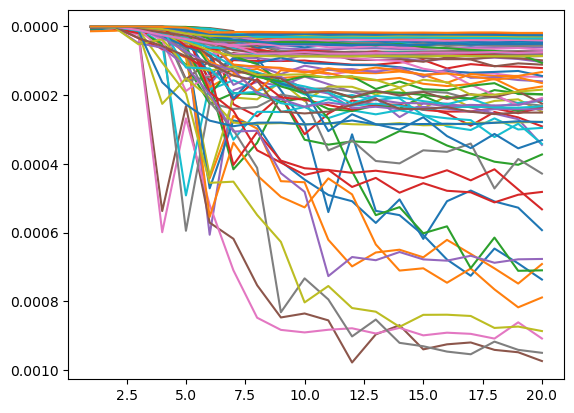

In [ ]:
picklefile1 = f"{BASE}/cleaned/groupped_spb2/tic375038081_allsectors_corrected.pickle"
picklefile2 = f"{BASE}/cleaned/groupped_spb1/tic177162802_allsectors_corrected.pickle"

with open(picklefile1, "rb") as f:
    sectors1 = pickle.load(f)

with open(picklefile2, "rb") as f:
    sectors2 = pickle.load(f)

sectors = sectors1 + sectors2

i = 0

plt.figure()
for sector in sectors:
    if getattr(sector, "tag", None) == "OK":
            npc = sector.pca_all.npc
            variance =  sector.pca_all.pc_variances
            npc_list = np.arange(1,npc+1)
            plt.plot(npc_list, variance)
            i+=1

print(i)
plt.gca().invert_yaxis()
plt.show()

In [ ]:
def local_variances_per_pc(dm, nbins=40):    
    X = dm.values  # shape: (ntime, ncols) ; PCs zitten vooraan
    ntime, ncols = X.shape


    window_size = int(np.floor(ntime / nbins))

    local_vars_per_pc = []
    # Ga t/m DM-rank (PC-kolommen), constant term (append_constant) zit op het einde
    n_pc = dm.rank  # aantal regressoren


    for i in range(n_pc):
        s = pd.Series(X[:, i], dtype='float64')
        lv = s.rolling(window=window_size).var().to_numpy()
        lv = lv[np.isfinite(lv)]
        local_vars_per_pc.append(lv)

    return local_vars_per_pc

def plot_pc_localvar_boxplots(dm, nbins=40):
    local_vars_per_pc = local_variances_per_pc(dm, nbins=nbins)
    n_pc = len(local_vars_per_pc)
    x = np.arange(1, n_pc+1)
    plt.boxplot(local_vars_per_pc, positions=x, showfliers=True)
    return local_vars_per_pc

def plot_trend_per_year(variance, year):
    maxlen = max(len(v) for v in variance)
    data = pd.DataFrame({
        f"sector{i+1}": np.pad(v, (0, maxlen - len(v)), constant_values=np.nan)
        for i, v in enumerate(variance)
    })

    data['Median'] = data.median(axis=1)
    data['Min'] = data.min(axis=1)
    data['Max'] = data.max(axis=1)
    plt.plot(npc_list, data['Median'], label=f'Year {year}')
    return data

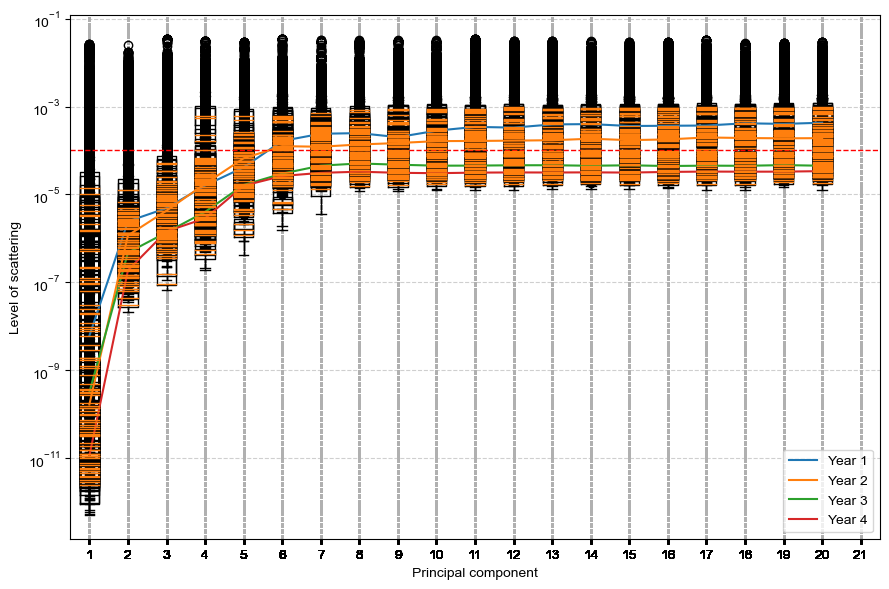

In [ ]:


plt.figure(figsize=(9,6))

variance_y1 = []
variance_y2 = []
variance_y3 = []
variance_y4 = []

for sector in sectors:
    if getattr(sector, "tag", None) == "OK": 
        _ = plot_pc_localvar_boxplots(sector.pca_all.dm, nbins=40)
        if sector.sector <= 13:
            variance_y1.append(sector.pca_all.pc_variances)
        elif sector.sector <= 39:
            variance_y2.append(sector.pca_all.pc_variances)
        elif sector.sector <= 69:
            variance_y3.append(sector.pca_all.pc_variances)
        else:
            variance_y4.append(sector.pca_all.pc_variances)

y1 = plot_trend_per_year(variance_y1, year=1)
y2 = plot_trend_per_year(variance_y2, year=2)
y3 = plot_trend_per_year(variance_y3, year=3)
y4 = plot_trend_per_year(variance_y4, year=4)

plt.axhline(1e-4, color='red', linestyle='--', linewidth=1)

plt.xlabel("Principal component")
plt.ylabel("Level of scattering")
plt.yticks([1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1])
plt.yscale('log')
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def exp_model(x, A, k, y_inf):
    return y_inf - A * np.exp(-k * x)

def fit_y(y, jaar, npc_list, err=None):
    x = np.asarray(npc_list, float)
    y_log = np.log10(y)

    p0 = [1.0, 0.5, y_log[-1]]  # startschatting

    # Controleer of er een geldige error-array is opgegeven
    if err is not None:
        err = np.asarray(err, float)
        # controleer lengte, en dat er geen nullen of negatieve waarden zijn
        if err.shape != y.shape:
            raise ValueError("Error array 'err' must have same shape as y.")
        if np.any(err <= 0):
            raise ValueError("Error values must be positive.")
        # curve_fit met weging
        params, cov = curve_fit(exp_model, x, y_log, p0=p0, sigma=err, absolute_sigma=True)
    else:
        # curve_fit zonder errors
        params, cov = curve_fit(exp_model, x, y_log, p0=p0)

    A, k, y_inf = params

    #bereken knik & threshold
    tau = 0#np.exp(k*6)
    npc_opt = 7 #-np.log(tau) / k + 1
    threshold_opt = 2e-5 #10**exp_model(npc_opt, *params)

    #plot
    if err is not None:
        # plot met error bars
        plt.errorbar(
            x, y,
            yerr=err,
            fmt='o',
            capsize=4,
            label=f"data year {jaar}"
        )
    else:
        # gewone scatter
        plt.scatter(x, y, label=f"data period {jaar}")

    # fitted curve
    x_fit = np.linspace(min(x), max(x), 300)
    y_fit_log = exp_model(x_fit, *params)
    y_fit = 10**y_fit_log
    plt.plot(x_fit, y_fit, linestyle='dashed', label=f"fit period {jaar}")
    
    return {"tau": tau, "npc": npc_opt, "treshhold": threshold_opt, "parameters": params, "covariance": cov}


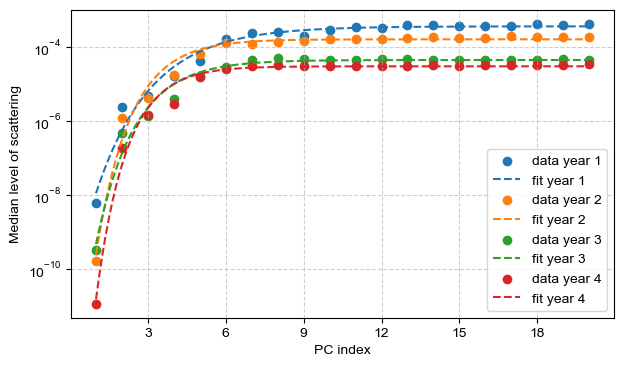

{'year 1': 0.0003634920792483451, 'year 2': 0.00016204758118996173, 'year 3': 4.463126858647087e-05, 'year 4': 3.0113825613253925e-05}


In [ ]:
y_list = [np.array(y1['Median']), np.array(y2['Median']), np.array(y3['Median']), np.array(y4['Median'])]
y_err = [np.array((y1['Max']-y1['Min'])/2), np.array((y2['Max']-y2['Min'])/2), np.array((y2['Max']-y2['Min'])/2), np.array((y2['Max']-y2['Min'])/2)]

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "font.family": "Arial",          # overal Arial
    "axes.grid": True,               # standaard grid aan
    "grid.linestyle": "--",          # optioneel: stippellijn
    "grid.alpha": 0.6,               # optioneel: transparantie
})

plt.figure(figsize=(7, 4))

y_lim = {}

for i, y in enumerate(y_list):
    uitkomst = fit_y(y, i + 1, npc_list, err=None) #y_err[i]
    y_lim[f"year {i + 1}"] = (10 ** uitkomst["parameters"][2])

# assen
plt.yscale("log")
plt.xlabel("PC index")
plt.ylabel("Median level of scattering")

# X-as: alleen gehele getallen, geen decimalen
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# legend & grid
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.savefig("fit.pdf")
plt.show()

print(y_lim)

